# Q-Learning with Gymnasium Taxi
## State encoding, rewards, Q-table convergence, exact Q*, learned policy, and rendered trained agent

This notebook uses the **built-in Gymnasium Taxi environment**, originally part of the OpenAI Gym Toy Text collection.

The taxi must:

1. navigate to the passenger;
2. pick up the passenger;
3. travel to the requested destination;
4. drop off the passenger correctly.

This is a strong tabular Q-Learning example because both the observation space and action space are discrete.

In [1]:
%pip install -q "gymnasium[toy-text]" imageio pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 28.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import imageio.v2 as imageio

from IPython.display import Image as IPyImage, display

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_rows", 600)
pd.set_option("display.max_columns", 20)

## 1. Environment and MDP Definition

### State space

The Taxi environment has **500 encoded states**.

A state combines:

- taxi row: 5 possibilities;
- taxi column: 5 possibilities;
- passenger location: 5 possibilities;
- destination: 4 possibilities.

Therefore,

$$
25\times5\times4=500.
$$

The environment encodes a state as a single integer.

### Action space

The six actions are:

- 0 = South
- 1 = North
- 2 = East
- 3 = West
- 4 = Pickup
- 5 = Dropoff

### Reward

The standard reward structure is:

$$
R=
\begin{cases}
+20, & \text{successful passenger delivery}\\
-10, & \text{illegal pickup or dropoff}\\
-1, & \text{ordinary time step}
\end{cases}
$$

### Terminal condition

The episode terminates after the passenger is successfully dropped off at the destination.

### Objective

Learn an efficient pickup-and-delivery policy while avoiding illegal pickup/dropoff actions and unnecessary movement.

Environment: Taxi-v4
Observation space: Discrete(500)
Action space: Discrete(6)
Example encoded state: 309
Decoded state:
  Taxi row: 3
  Taxi column: 0
  Passenger location: 2
  Destination: 1


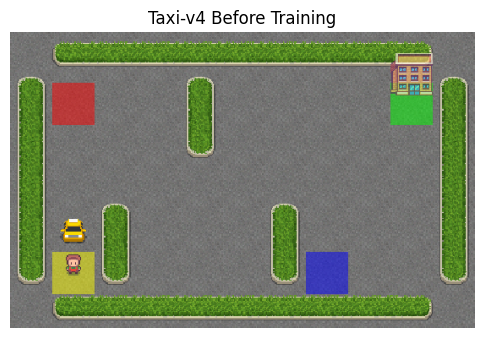

In [3]:
def make_taxi(render_mode=None):
    # Current Gymnasium uses Taxi-v4. The fallback keeps the notebook usable
    # on older Colab images that may still provide Taxi-v3.
    for env_id in ["Taxi-v4", "Taxi-v3"]:
        try:
            return gym.make(env_id, render_mode=render_mode), env_id
        except gym.error.Error:
            pass
    raise RuntimeError("Taxi environment is not available in this Gymnasium installation.")

env, ENV_ID = make_taxi()
render_env, _ = make_taxi(render_mode="rgb_array")

GAMMA = 0.95
ACTION_NAMES = ["South", "North", "East", "West", "Pickup", "Dropoff"]

print("Environment:", ENV_ID)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

state, info = render_env.reset(seed=7)

taxi_row, taxi_col, passenger_loc, destination = render_env.unwrapped.decode(state)

print("Example encoded state:", state)
print("Decoded state:")
print("  Taxi row:", taxi_row)
print("  Taxi column:", taxi_col)
print("  Passenger location:", passenger_loc)
print("  Destination:", destination)

plt.figure(figsize=(6, 6))
plt.imshow(render_env.render())
plt.axis("off")
plt.title(f"{ENV_ID} Before Training")
plt.show()

## 2. Q-Learning Update

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_aQ(S_{t+1},a)
-
Q(S_t,A_t)
\right].
$$

The Q-table has shape

$$
500\times6.
$$

## 3. Exact Optimal Q-Table $Q^*$

Taxi exposes a finite tabular transition model. We use value iteration to calculate an exact reference $Q^*$.

This gives a target against which the learned Q-table can be compared.

In [4]:
def value_iteration_from_model(env, gamma=0.95, theta=1e-12):
    """Compute exact Q* from the environment's tabular transition model P."""
    P = env.unwrapped.P
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)

    while True:
        V_new = np.zeros_like(V)

        for s in range(n_states):
            action_values = []

            for a in range(n_actions):
                q = 0.0

                for prob, s_next, reward, terminated in P[s][a]:
                    bootstrap = 0.0 if terminated else gamma * V[s_next]
                    q += prob * (reward + bootstrap)

                action_values.append(q)

            V_new[s] = max(action_values)

        if np.max(np.abs(V_new - V)) < theta:
            V = V_new
            break

        V = V_new

    Q_star = np.zeros((n_states, n_actions))

    for s in range(n_states):
        for a in range(n_actions):
            for prob, s_next, reward, terminated in P[s][a]:
                bootstrap = 0.0 if terminated else gamma * V[s_next]
                Q_star[s, a] += prob * (reward + bootstrap)

    return Q_star

In [5]:
Q_star = value_iteration_from_model(env, gamma=GAMMA)

q_star_df = pd.DataFrame(
    Q_star,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

print("Exact optimal Q-table Q*:")
display(q_star_df.round(3))

Exact optimal Q-table Q*:


,South,North,East,West,Pickup,Dropoff
State 0,14.295,16.100,14.295,16.100,18.000,7.100
State 1,2.752,3.949,2.752,3.949,5.210,-5.051
State 2,7.933,9.404,7.933,9.404,10.951,0.404
State 3,3.949,5.210,3.949,5.210,6.537,-3.790
State 4,-3.275,-4.111,-3.275,-4.111,-13.111,-13.111
State 5,5.210,3.949,5.210,3.949,-5.051,-5.051
State 6,-3.275,-4.111,-3.275,-4.111,-13.111,-13.111
State 7,-0.493,-1.468,-0.493,-1.468,-10.468,-10.468
State 8,5.210,3.949,2.752,3.949,-5.051,-5.051
State 9,0.534,-0.493,-1.468,-0.493,-9.493,-9.493


## 4. Train the Q-Learning Agent

Training uses random initial Taxi states supplied by the environment.

Parameters:

$$
\alpha=0.25,\qquad \gamma=0.95.
$$

The first 60 individual updates are stored for inspection.

In [6]:
def train_q_learning(
    n_episodes=30000,
    alpha=0.25,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.9997,
    seed=11
):
    rng = np.random.default_rng(seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))

    history = []
    update_log = []
    visit_counts = np.zeros(n_states, dtype=int)

    epsilon = epsilon_start
    update_number = 0

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(1, 201):
            visit_counts[state] += 1

            if rng.random() < epsilon:
                action = int(rng.integers(n_actions))
                selection = "explore"
            else:
                best_actions = np.flatnonzero(np.isclose(Q[state], Q[state].max()))
                action = int(rng.choice(best_actions))
                selection = "exploit"

            next_state, reward, terminated, truncated, _ = env.step(action)

            old_q = Q[state, action]
            max_next_q = 0.0 if terminated else np.max(Q[next_state])
            target = reward if terminated else reward + gamma * max_next_q
            td_error = target - old_q
            Q[state, action] += alpha * td_error

            update_number += 1

            if update_number <= 60:
                update_log.append({
                    "Update": update_number,
                    "Episode": episode,
                    "Step": step,
                    "State": state,
                    "Action": ACTION_NAMES[action],
                    "Reward": reward,
                    "Next State": next_state,
                    "Max Next Q": max_next_q,
                    "Old Q": old_q,
                    "TD Target": target,
                    "TD Error": td_error,
                    "New Q": Q[state, action],
                    "Epsilon": epsilon
                })

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        visited = visit_counts > 0
        rmse = np.sqrt(np.mean((Q[visited] - Q_star[visited]) ** 2))

        history.append({
            "Episode": episode,
            "Return": total_reward,
            "Episode Length": step,
            "Epsilon": epsilon,
            "Visited States": visited.sum(),
            "Q RMSE on Visited States": rmse
        })

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, pd.DataFrame(history), pd.DataFrame(update_log), visit_counts

Q, history, update_log, visit_counts = train_q_learning()

print("Training complete.")
print("Visited states:", int((visit_counts > 0).sum()))
print("Final RMSE on visited states:", history["Q RMSE on Visited States"].iloc[-1])

Training complete.
Visited states: 400
Final RMSE on visited states: 1.3269621840450838


## 5. First 60 Q-Value Updates

In [7]:
display(update_log.round(4))

,Update,Episode,Step,State,Action,Reward,Next State,Max Next Q,Old Q,TD Target,TD Error,New Q,Epsilon
0,1,1,1,124,Pickup,-10,124,0.00,0.0000,-10.0000,-10.0000,-2.5000,1.0
1,2,1,2,124,East,-1,124,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0
2,3,1,3,124,East,-1,124,0.00,-0.2500,-1.0000,-0.7500,-0.4375,1.0
3,4,1,4,124,South,-1,224,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0
4,5,1,5,224,West,-1,204,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0
5,6,1,6,204,South,-1,304,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0
6,7,1,7,304,Dropoff,-10,304,0.00,0.0000,-10.0000,-10.0000,-2.5000,1.0
7,8,1,8,304,East,-1,304,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0
8,9,1,9,304,Dropoff,-10,304,0.00,-2.5000,-10.0000,-7.5000,-4.3750,1.0
9,10,1,10,304,North,-1,204,0.00,0.0000,-1.0000,-1.0000,-0.2500,1.0


## 6. Convergence Graph

Taxi contains states that are not normally reachable during an episode. Therefore, the convergence graph reports RMSE over the states actually visited during training.

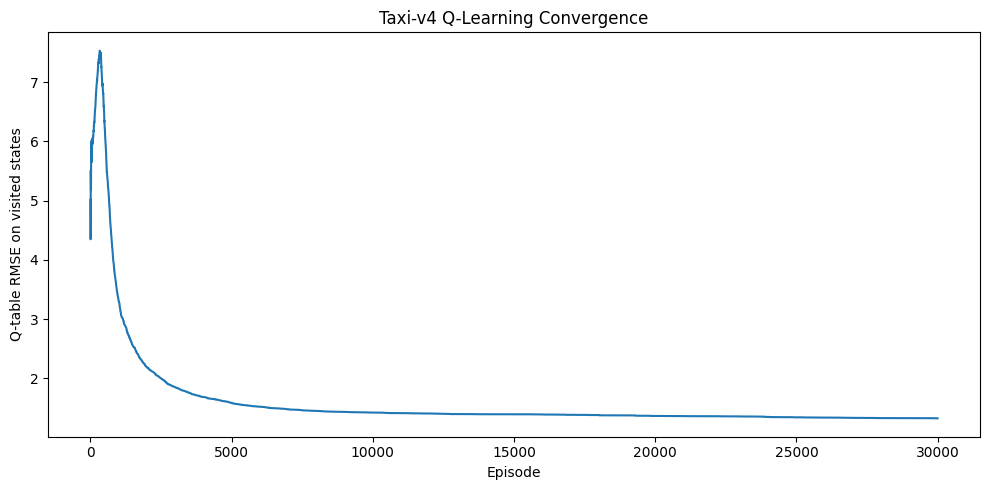

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history["Episode"], history["Q RMSE on Visited States"])
plt.xlabel("Episode")
plt.ylabel("Q-table RMSE on visited states")
plt.title(f"{ENV_ID} Q-Learning Convergence")
plt.tight_layout()
plt.show()

## 7. Learned Q-Table

Taxi has 500 states and 6 actions, so its complete Q-table contains 3,000 values.

The full table is displayed below.

In [9]:
learned_q_df = pd.DataFrame(
    Q,
    index=[f"State {s}" for s in range(env.observation_space.n)],
    columns=ACTION_NAMES
)

display(learned_q_df.round(3))

,South,North,East,West,Pickup,Dropoff
State 0,0.000,0.000,0.000,0.000,0.000,0.000
State 1,2.752,3.949,2.752,3.949,5.210,-5.051
State 2,7.933,9.404,7.933,9.404,10.951,0.404
State 3,3.949,5.210,3.949,5.210,6.537,-3.790
State 4,-3.275,-5.741,-4.744,-5.763,-14.828,-14.832
State 5,0.000,0.000,0.000,0.000,0.000,0.000
State 6,-4.768,-6.692,-3.275,-7.336,-15.593,-14.988
State 7,-3.574,-3.402,-0.493,-5.066,-13.783,-13.079
State 8,5.210,3.572,2.416,3.863,-5.620,-5.499
State 9,0.534,-2.444,-2.311,-1.638,-10.670,-11.718


## 8. Compare Learned Q with Exact $Q^*$

The next table places the learned and exact values side-by-side.

In [10]:
comparison = pd.concat(
    {"Learned Q": learned_q_df.round(3), "Exact Q*": q_star_df.round(3)},
    axis=1
)

display(comparison)

Learned Q                                         Exact Q*          \
              South   North    East    West  Pickup Dropoff    South   North   
State 0       0.000   0.000   0.000   0.000   0.000   0.000   14.295  16.100   
State 1       2.752   3.949   2.752   3.949   5.210  -5.051    2.752   3.949   
State 2       7.933   9.404   7.933   9.404  10.951   0.404    7.933   9.404   
State 3       3.949   5.210   3.949   5.210   6.537  -3.790    3.949   5.210   
State 4      -3.275  -5.741  -4.744  -5.763 -14.828 -14.832   -3.275  -4.111   
State 5       0.000   0.000   0.000   0.000   0.000   0.000    5.210   3.949   
State 6      -4.768  -6.692  -3.275  -7.336 -15.593 -14.988   -3.275  -4.111   
State 7      -3.574  -3.402  -0.493  -5.066 -13.783 -13.079   -0.493  -1.468   
State 8       5.210   3.572   2.416   3.863  -5.620  -5.499    5.210   3.949   
State 9       0.534  -2.444  -2.311  -1.638 -10.670 -11.718    0.534  -0.493   
State 10      0.000   0.000   0.000   0.000   0.000   0.000   10.951   9.404   
State 11      1.614  -4.666  -3.035  -5.567 -10.372  -9.770    1.614   0.534   
State 12     -1.468  -3.792  -2.257  -4.634 -14.553 -13.240   -1.468  -2.395   
State 13     -2.571  -2.710   0.534  -2.188 -11.532 -14.677    0.534  -0.493   
State 14     -1.468  -4.219  -4.017  -5.849 -16.626 -13.135   -1.468  -2.395   
State 15      0.000   0.000   0.000   0.000   0.000   0.000    6.537   5.210   
State 16     16.100  18.000  16.100  18.000   9.000  20.000   16.100  18.000   
State 17      6.537   5.210   6.537   5.210  -3.790   3.949    6.537   5.210   
State 18     12.580  10.951   9.404  10.951   1.951   9.404   12.580  10.951   
State 19      7.933   6.537   7.933   6.537  -2.463   5.210    7.933   6.537   
State 20      0.000   0.000   0.000   0.000   0.000   0.000   12.580  14.295   
State 21      1.604   2.751   2.746   3.949  -6.251  -6.248    1.614   2.752   
State 22      6.537   7.933   7.933   9.404  -1.067  -1.067    6.537   7.933   
State 23      2.752   3.949   3.949   5.210  -5.051  -5.051    2.752   3.949   
State 24     -2.395  -5.892  -7.334  -6.755 -15.027 -14.302   -2.395  -3.275   
State 25      0.000   0.000   0.000   0.000   0.000   0.000    6.537   5.210   
State 26     -2.395  -4.540  -3.864  -5.278 -13.917 -13.332   -2.395  -3.275   
State 27      0.534  -1.818  -2.805  -2.957  -9.900  -9.909    0.534  -0.493   
State 28      3.636   0.264  -0.337   3.949  -7.298  -9.156    3.949   2.752   
State 29     -0.493  -3.248  -3.500  -2.491 -12.299 -11.953   -0.493  -1.468   
State 30      0.000   0.000   0.000   0.000   0.000   0.000    9.404   7.933   
State 31      0.534  -2.545  -1.322  -2.033 -14.083 -12.102    0.534  -0.493   
State 32     -0.493  -3.750  -4.091  -3.576 -11.740 -14.485   -0.493  -1.468   
State 33      1.614   0.077  -1.397  -1.351  -9.638  -9.339    1.614   0.534   
State 34     -0.493  -6.356  -3.343  -5.756 -11.687 -13.414   -0.493  -1.468   
State 35      0.000   0.000   0.000   0.000   0.000   0.000    7.933   6.537   
State 36     14.295  16.100  16.100  18.000   7.100   7.100   14.295  16.100   
State 37      7.933   6.536   6.537   5.209  -2.463  -2.464    7.933   6.537   
State 38     10.950   9.403   9.403  10.951   0.404   0.404   10.951   9.404   
State 39      9.404   7.933   7.933   6.535  -1.067  -1.067    9.404   7.933   
State 40      0.000   0.000   0.000   0.000   0.000   0.000    7.933   6.537   
State 41     -1.468  -3.538  -5.601  -5.905 -12.742 -15.015   -1.468  -2.395   
State 42      2.752   1.413  -0.219   1.459  -8.285  -8.014    2.752   1.614   
State 43     -0.493  -1.845  -2.536  -1.891 -10.794 -10.739   -0.493  -1.468   
State 44      0.129   0.550   2.752   0.145  -8.156  -7.860    0.534   1.614   
State 45      0.000   0.000   0.000   0.000   0.000   0.000   10.951  12.580   
State 46     -0.109   0.293   2.752  -0.212  -8.464  -8.069    0.534   1.614   
State 47      3.872   4.620   6.537   4.972  -3.837  -4.194    3.949   5.210   
State 48  

## 9. Evaluate the Trained Agent

In [11]:
def evaluate_agent(Q, n_episodes=500):
    returns = []
    successes = 0
    lengths = []

    for episode in range(n_episodes):
        state, _ = env.reset(seed=50000 + episode)
        total_reward = 0.0

        for step in range(1, 201):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            if terminated or truncated:
                successes += int(terminated)
                break

        returns.append(total_reward)
        lengths.append(step)

    return {
        "Success Rate": successes / n_episodes,
        "Mean Return": np.mean(returns),
        "Mean Episode Length": np.mean(lengths)
    }

evaluation = evaluate_agent(Q)
display(pd.DataFrame([evaluation]).round(3))

,Success Rate,Mean Return,Mean Episode Length
0,1.0,8.036,12.964


## 10. Run the Trained Taxi

The next cell records one greedy episode using the actual Gymnasium Taxi renderer.

In [12]:
def save_gif(frames, filename, duration=0.45):
    imageio.mimsave(filename, frames, duration=duration, loop=0)
    display(IPyImage(filename=filename))

Initial encoded state: 341
Initial decoded state: (3, 2, 0, 1)
Actions: ['North', 'West', 'North', 'North', 'West', 'Pickup', 'South', 'South', 'East', 'East', 'North', 'North', 'East', 'East', 'Dropoff']
Total reward: 6.0


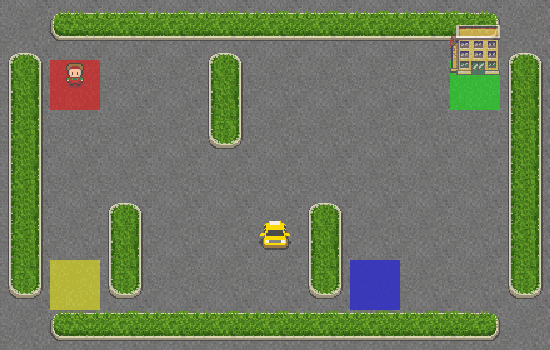

In [13]:
def record_trained_agent(Q, filename="taxi_trained_agent.gif", seed=123):
    frames = []
    state, _ = render_env.reset(seed=seed)
    initial_state = state
    frames.append(render_env.render())

    actions = []
    total_reward = 0.0

    for _ in range(200):
        action = int(np.argmax(Q[state]))
        actions.append(ACTION_NAMES[action])

        state, reward, terminated, truncated, _ = render_env.step(action)
        total_reward += reward
        frames.append(render_env.render())

        if terminated or truncated:
            break

    decoded = render_env.unwrapped.decode(initial_state)

    print("Initial encoded state:", initial_state)
    print("Initial decoded state:", decoded)
    print("Actions:", actions)
    print("Total reward:", total_reward)

    save_gif(frames, filename, duration=0.40)

record_trained_agent(Q)

## 11. Portfolio Takeaway

Taxi demonstrates Q-Learning on a larger finite state space:

$$
500\text{ states}\times6\text{ actions}.
$$

It also illustrates why state encoding matters: one integer compactly represents taxi location, passenger status, and destination.